In [1]:
import numpy as np
import pandas as pd
import sctop as top
import anndata as ad
import pickle

def processed_from_adata_like_basis(adata, cell_ids) -> pd.DataFrame:
    """
    Replicates the exact pattern you used for basis construction:
      cell_data_sparse = adata[cell_ids, :].X.T
      df = DataFrame(..., index=adata.var_names, columns=cell_ids)
      process(df, average=False)
    Returns genes x cells processed matrix.
    """
    if isinstance(cell_ids, (pd.Index, pd.Series)):
        cell_ids = cell_ids.astype(str).tolist()
    else:
        cell_ids = list(cell_ids)
    if len(cell_ids) == 0:
        raise ValueError("cell_ids is empty.")

    ad = adata[cell_ids, :]
    X = ad.X
    if hasattr(X, "toarray"):
        X = X.toarray()
    X = np.asarray(X, dtype=np.float32)           # cells x genes
    df = pd.DataFrame(X.T, index=ad.var_names, columns=ad.obs_names)  # genes x cells
    return top.process(df, average=False)


def score_and_predict(basis: pd.DataFrame, proc_sample_gxc: pd.DataFrame):
    proj = top.score(basis, proc_sample_gxc, full_output=False)  # celltypes x cells
    pred = proj.idxmax(axis=0)

    vals = proj.to_numpy(np.float32)
    part = np.partition(vals, kth=vals.shape[0] - 2, axis=0)
    margin = pd.Series(part[-1, :] - part[-2, :], index=proj.columns, dtype=float)
    return pred, margin, proj


def slerp_columns(U: np.ndarray, v: np.ndarray, alpha: float, eps: float = 1e-12) -> np.ndarray:
    """
    Slerp each column of U (GxN) toward v (G,).
    Assumes vectors are nonzero; normalizes defensively.
    """
    # Normalize inputs
    U = U / (np.linalg.norm(U, axis=0, keepdims=True) + eps)
    v = v / (np.linalg.norm(v) + eps)

    dots = np.clip((U * v[:, None]).sum(axis=0), -1.0, 1.0)
    omegas = np.arccos(dots)                      # (N,)
    so = np.sin(omegas) + eps

    near = omegas < 1e-6
    W = np.empty_like(U, dtype=np.float32)

    if np.any(~near):
        omega = omegas[~near]
        s0 = np.sin((1.0 - alpha) * omega) / so[~near]
        s1 = np.sin(alpha * omega) / so[~near]
        W[:, ~near] = (U[:, ~near] * s0[None, :]) + (v[:, None] * s1[None, :])

    if np.any(near):
        W[:, near] = (1.0 - alpha) * U[:, near] + alpha * v[:, None]
    
    W = W / (np.linalg.norm(W, axis=0, keepdims=True) + eps)
    return W.astype(np.float32)


def perturb_toward_basis(
    proc_source_gxc: pd.DataFrame,   # genes x cells (processed)
    basis: pd.DataFrame,             # genes x celltypes (processed prototypes)
    target_label: str,
    alphas: np.ndarray,
) -> list[pd.DataFrame]:
    """
    For each alpha, returns processed genes x cells matrix:
      z_alpha = slerp(z, b_target, alpha)
    IMPORTANT: we align genes by intersection and keep ordering consistent.
    """
    if target_label not in basis.columns:
        raise ValueError(f"target_label='{target_label}' not found in basis.columns")

    common = np.intersect1d(proc_source_gxc.index.values, basis.index.values)
    if common.size == 0:
        raise ValueError("No common genes between processed sample and basis.")

    Z = proc_source_gxc.loc[common].to_numpy(np.float32, copy=False)   # G x N
    b = basis.loc[common, target_label].to_numpy(np.float32, copy=False)  # (G,)

    out = []
    cols = proc_source_gxc.columns
    for a in alphas:
        Za = slerp_columns(Z, b, float(a))
        out.append(pd.DataFrame(Za, index=common, columns=cols))
    return out


def run_processed_space_experiment(
    adata,
    basis: pd.DataFrame,
    source_cell_ids,
    source_label: str,
    target_label: str,
    alphas: np.ndarray,
    max_cells: int | None = None,
    random_state: int = 0,
    filter_to_correct_at_alpha0: bool = True,
    verbose: bool = True,
):
    """
    Steps:
      1) build proc_source exactly like your manual pipeline
      2) sanity check alpha=0 predictions
      3) optionally keep only cells correctly predicted as source at alpha=0
      4) slerp toward target basis vector for each alpha
      5) report flip curves + per-cell thresholds
    """
    rng = np.random.default_rng(random_state)

    src_ids = np.array(list(source_cell_ids), dtype=str)
    if src_ids.size == 0:
        raise ValueError("No source cells provided.")

    if max_cells is not None and src_ids.size > max_cells:
        src_ids = rng.choice(src_ids, size=max_cells, replace=False)

    proc_src = processed_from_adata_like_basis(adata, src_ids)

    pred0, margin0, proj0 = score_and_predict(basis, proc_src)

    if verbose:
        frac0 = float((pred0 == source_label).mean())
        print(f"[Sanity] alpha=0 P(pred=={source_label}) = {frac0:.3f}")

    if filter_to_correct_at_alpha0:
        keep = pred0[pred0 == source_label].index
        if keep.size == 0:
            raise ValueError(
                f"After filtering to alpha=0 correct cells, none remain for source_label={source_label}. "
                f"Check naming: source_label must match basis.columns exactly."
            )
        proc_src = proc_src[keep]
        pred0 = pred0.loc[keep]
        margin0 = margin0.loc[keep]

    proc_list = perturb_toward_basis(proc_src, basis, target_label=target_label, alphas=alphas)

    preds = []
    frac_stay = []
    frac_target = []

    for proc_df in proc_list:
        pred, margin, _ = score_and_predict(basis, proc_df)
        preds.append(pred)
        frac_stay.append(float((pred == source_label).mean()))
        frac_target.append(float((pred == target_label).mean()))

    frac_stay = np.array(frac_stay, dtype=float)
    frac_target = np.array(frac_target, dtype=float)

    cells = preds[0].index
    alpha_leave = pd.Series(np.nan, index=cells, dtype=float)
    alpha_hit = pd.Series(np.nan, index=cells, dtype=float)
    for cell in cells:
        for a, pred in zip(alphas, preds):
            if np.isnan(alpha_leave[cell]) and pred.loc[cell] != source_label:
                alpha_leave[cell] = float(a)
            if np.isnan(alpha_hit[cell]) and pred.loc[cell] == target_label:
                alpha_hit[cell] = float(a)
            if not np.isnan(alpha_leave[cell]) and not np.isnan(alpha_hit[cell]):
                break

    idx_leave50 = np.where(frac_stay <= 0.5)[0]
    alpha50_leave = float(alphas[idx_leave50[0]]) if idx_leave50.size else np.nan

    idx_hit50 = np.where(frac_target >= 0.5)[0]
    alpha50_hit = float(alphas[idx_hit50[0]]) if idx_hit50.size else np.nan

    return {
        "alphas": alphas,
        "proc_source_used": proc_src,         # processed baseline cells used
        "pred_alpha0": pred0,
        "margin_alpha0": margin0,
        "frac_stay_source": frac_stay,
        "frac_become_target": frac_target,
        "preds_per_alpha": preds,
        "alpha_leave_source_per_cell": alpha_leave,
        "alpha_become_target_per_cell": alpha_hit,
        "alpha50_leave_source": alpha50_leave,
        "alpha50_become_target": alpha50_hit,
    }

In [2]:
def plot_flip_curves(result, title="Perturbation flip curves", output_file = None):
    import matplotlib.pyplot as plt
    alphas = result["alphas"]
    plt.figure(figsize=(6,4))
    plt.plot(alphas, result["frac_stay_source"], label="P(stay source)")
    plt.plot(alphas, result["frac_become_target"], label="P(become target)")
    plt.xlabel("alpha")
    plt.ylabel("fraction")
    plt.ylim(-0.02, 1.02)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    if output_file:
        plt.savefig(output_file)
    plt.show()

In [8]:
adata = ad.read_h5ad('./habbermann.h5ad')

In [9]:
adata = adata[~adata.obs['cell_type'].isin(['MUC5B+', 'MUC5AC+ High', 'Ciliated', 'Differentiating Ciliated'])]


Creating basis with single train-test split

Building cell type basis (parallelized)...


Creating basis (parallel): 100%|██████████| 8/8 [00:01<00:00,  4.83it/s]


Basis created: (33694, 8)
Total training cells: 15002
Total test cells: 3754

Scoring 3754 test cells (parallel, 4 workers)...


Scoring chunks (parallel): 100%|██████████| 10/10 [00:06<00:00,  1.62it/s]



FINAL RESULTS

Accuracy (Top-1): 0.7344
Top-3 Accuracy: 0.8775
Unspecified Rate: 0.0005
F1 Score (Macro): 0.5907
F1 Score (Weighted): 0.7041
Precision (Macro): 0.6480
Precision (Weighted): 0.8648
Recall (Macro): 0.7499
Recall (Weighted): 0.7344

Generating performance plots...


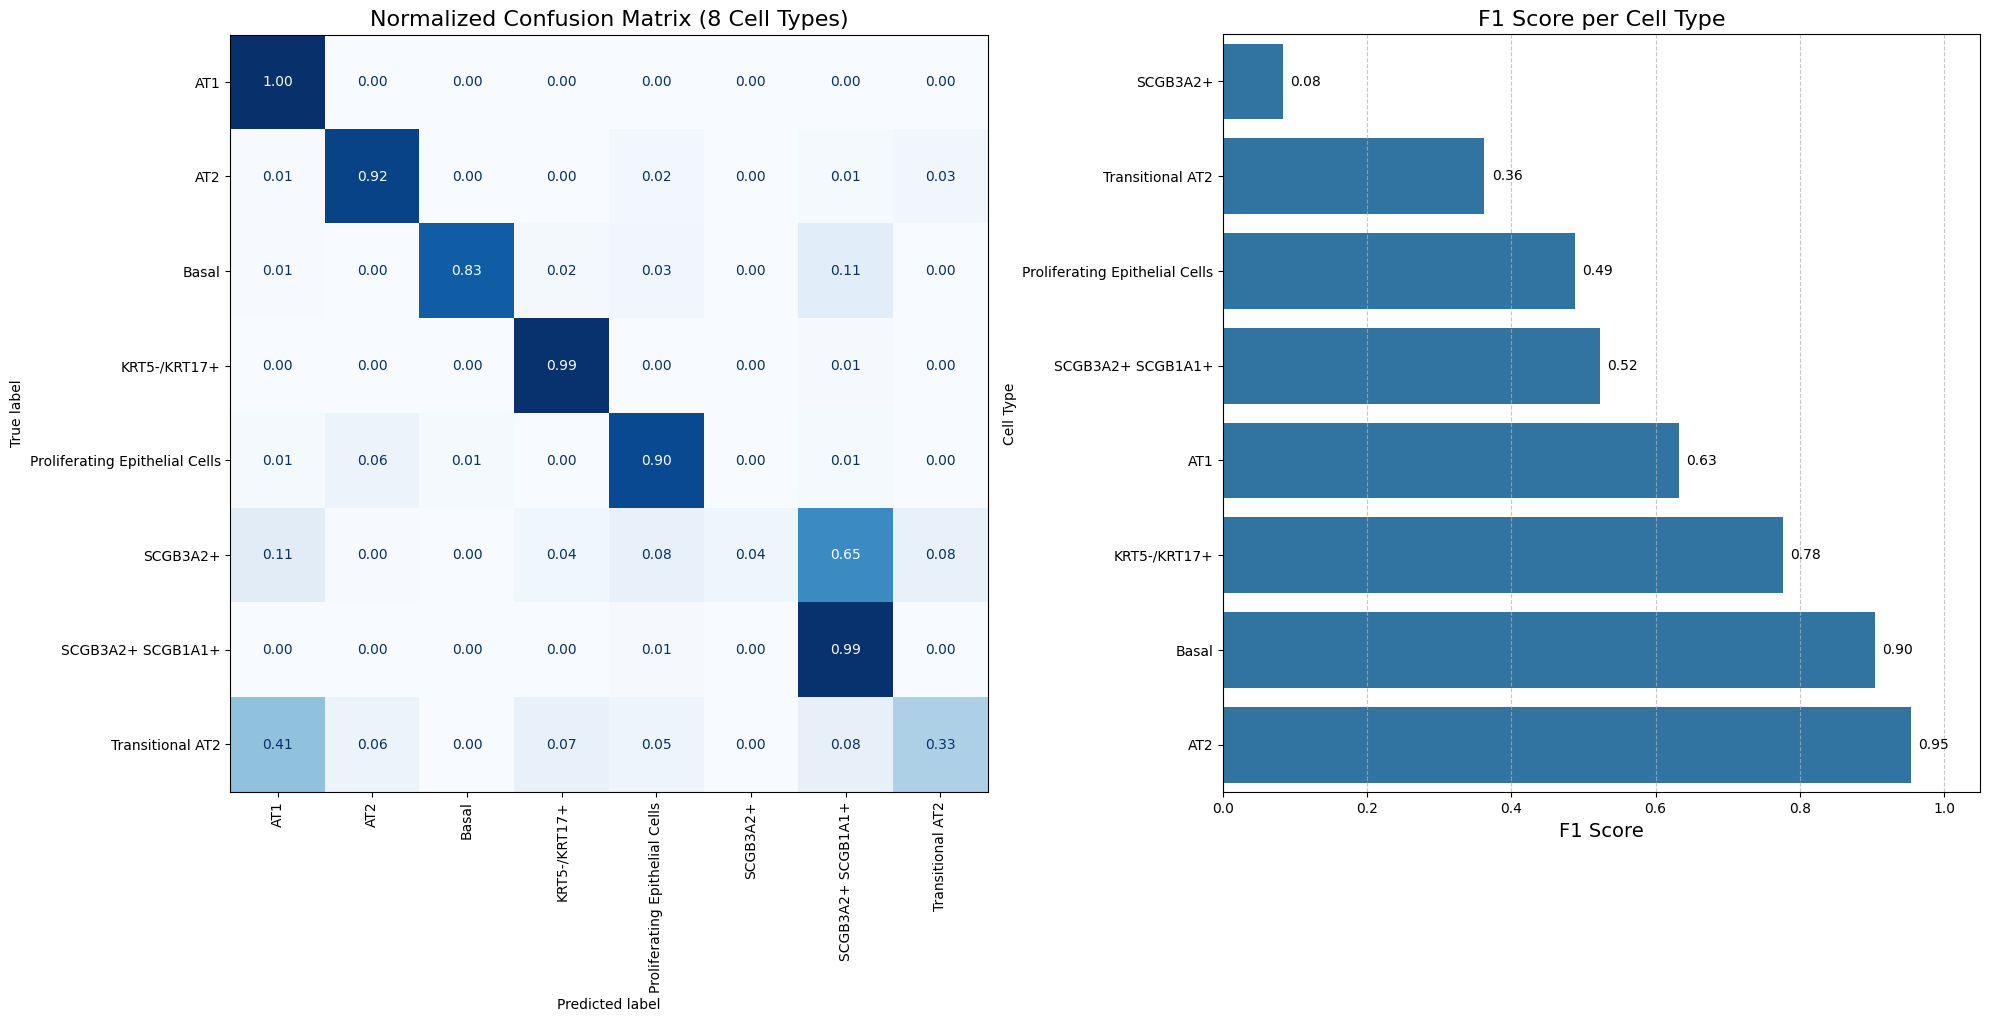

In [10]:
results = top.create_basis(adata, 'cell_type', 100)

In [11]:
# with open('planer_basis_with_transitional.pkl', 'rb') as f:
#     results = pickle.load(f)

basis = results['basis']

In [13]:
basis.columns

Index(['AT1', 'AT2', 'Basal', 'KRT5-/KRT17+', 'Proliferating Epithelial Cells',
       'SCGB3A2+', 'SCGB3A2+ SCGB1A1+', 'Transitional AT2'],
      dtype='object')

[Sanity] alpha=0 P(pred==SCGB3A2+) = 0.055


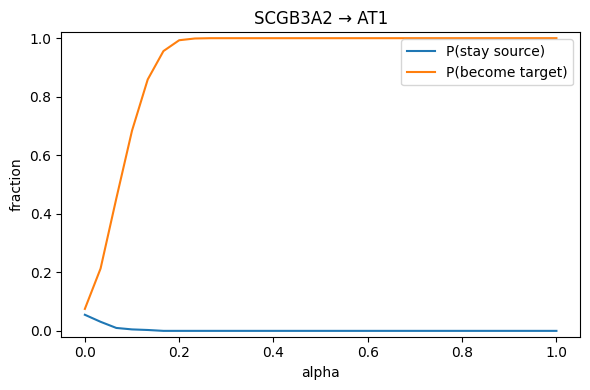

In [15]:
alphas = np.linspace(0, 1.0, 31)

src_ids = adata.obs_names[adata.obs["cell_type"] == "SCGB3A2+"]

res = run_processed_space_experiment(
    adata=adata,
    basis=basis,
    source_cell_ids=src_ids,
    source_label="SCGB3A2+",
    target_label="AT1",
    alphas=alphas,
    max_cells=1000,
    random_state=0,
    filter_to_correct_at_alpha0=False,
    verbose=True,
)

plot_flip_curves(res, "SCGB3A2 → AT1", output_file='SCGB3A2_to_AT1.png')


[Sanity] alpha=0 P(pred==SCGB3A2+) = 0.055


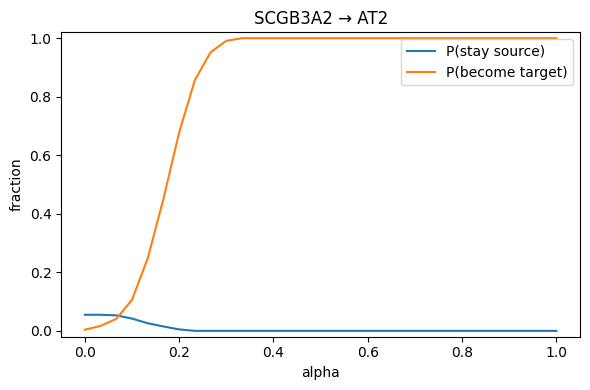

In [16]:
alphas = np.linspace(0, 1.0, 31)

src_ids = adata.obs_names[adata.obs["cell_type"] == "SCGB3A2+"]

res = run_processed_space_experiment(
    adata=adata,
    basis=basis,
    source_cell_ids=src_ids,
    source_label="SCGB3A2+",
    target_label="AT2",
    alphas=alphas,
    max_cells=1000,
    random_state=0,
    filter_to_correct_at_alpha0=False,
    verbose=True,
)

plot_flip_curves(res, "SCGB3A2 → AT2", output_file='SCGB3A2_to_AT2.png')


[Sanity] alpha=0 P(pred==SCGB3A2+) = 0.055


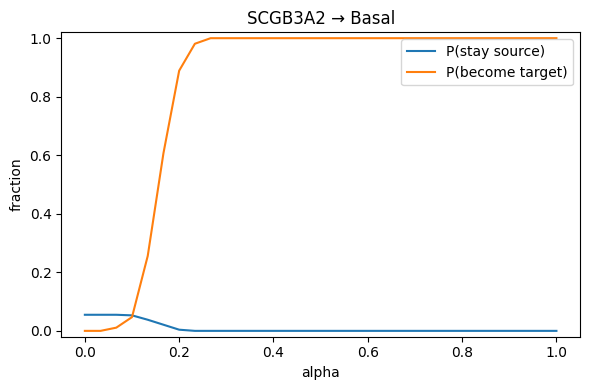

In [17]:
alphas = np.linspace(0, 1.0, 31)

src_ids = adata.obs_names[adata.obs["cell_type"] == "SCGB3A2+"]

res = run_processed_space_experiment(
    adata=adata,
    basis=basis,
    source_cell_ids=src_ids,
    source_label="SCGB3A2+",
    target_label="Basal",
    alphas=alphas,
    max_cells=1000,
    random_state=0,
    filter_to_correct_at_alpha0=False,
    verbose=True,
)

plot_flip_curves(res, "SCGB3A2 → Basal", output_file='SCGB3A2_to_Basal.png')


[Sanity] alpha=0 P(pred==SCGB3A2+) = 0.055


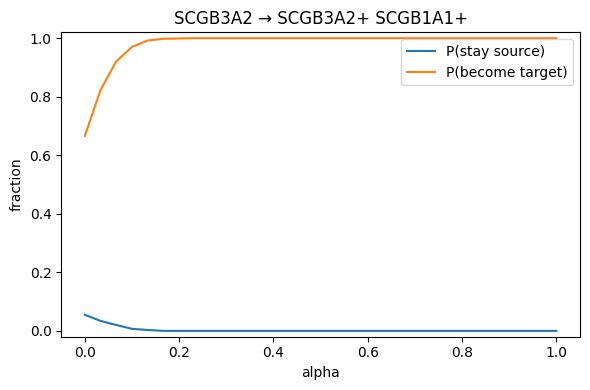

In [18]:
alphas = np.linspace(0, 1.0, 31)

src_ids = adata.obs_names[adata.obs["cell_type"] == "SCGB3A2+"]

res = run_processed_space_experiment(
    adata=adata,
    basis=basis,
    source_cell_ids=src_ids,
    source_label="SCGB3A2+",
    target_label="SCGB3A2+ SCGB1A1+",
    alphas=alphas,
    max_cells=1000,
    random_state=0,
    filter_to_correct_at_alpha0=False,
    verbose=True,
)

plot_flip_curves(res, "SCGB3A2 → SCGB3A2+ SCGB1A1+", output_file='SCGB3A2_to_SCGB1A1.png')


[Sanity] alpha=0 P(pred==SCGB3A2+ SCGB1A1+) = 0.996


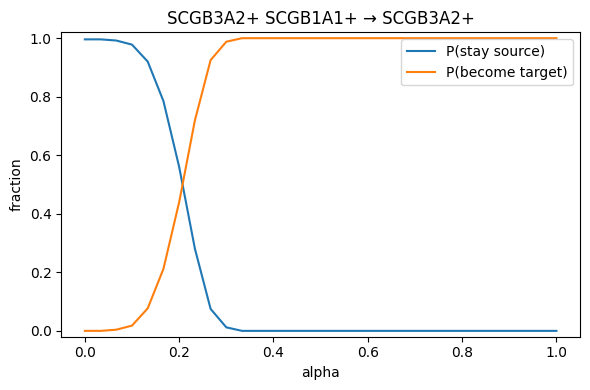

In [19]:
alphas = np.linspace(0, 1.0, 31)

src_ids = adata.obs_names[adata.obs["cell_type"] == "SCGB3A2+ SCGB1A1+"]

res = run_processed_space_experiment(
    adata=adata,
    basis=basis,
    source_cell_ids=src_ids,
    source_label="SCGB3A2+ SCGB1A1+",
    target_label="SCGB3A2+",
    alphas=alphas,
    max_cells=1000,
    random_state=0,
    filter_to_correct_at_alpha0=False,
    verbose=True,
)

plot_flip_curves(res, "SCGB3A2+ SCGB1A1+ → SCGB3A2+", output_file='SCGB1A1_to_SCGB3A2.png')


[Sanity] alpha=0 P(pred==SCGB3A2+ SCGB1A1+) = 0.996


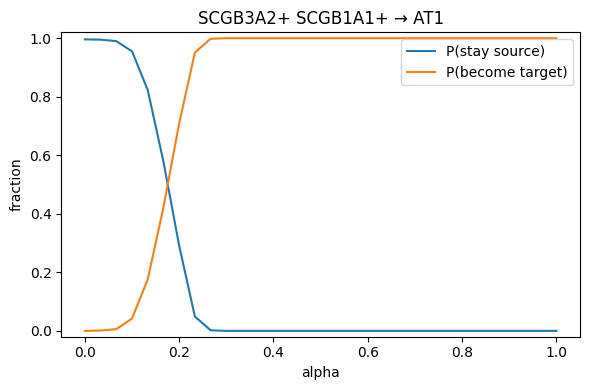

In [20]:
alphas = np.linspace(0, 1.0, 31)

src_ids = adata.obs_names[adata.obs["cell_type"] == "SCGB3A2+ SCGB1A1+"]

res = run_processed_space_experiment(
    adata=adata,
    basis=basis,
    source_cell_ids=src_ids,
    source_label="SCGB3A2+ SCGB1A1+",
    target_label="AT1",
    alphas=alphas,
    max_cells=1000,
    random_state=0,
    filter_to_correct_at_alpha0=False,
    verbose=True,
)

plot_flip_curves(res, "SCGB3A2+ SCGB1A1+ → AT1", output_file='SCGB1A1_to_AT1.png')


[Sanity] alpha=0 P(pred==SCGB3A2+ SCGB1A1+) = 0.996


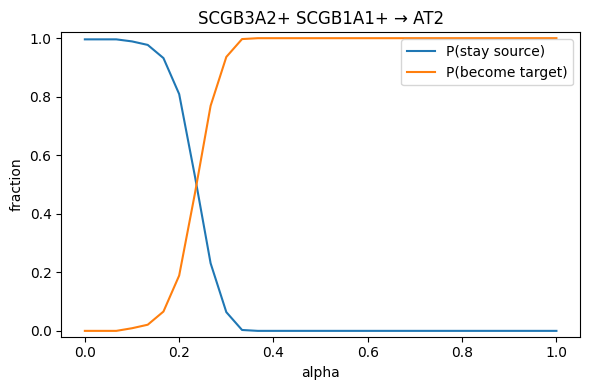

In [21]:
alphas = np.linspace(0, 1.0, 31)

src_ids = adata.obs_names[adata.obs["cell_type"] == "SCGB3A2+ SCGB1A1+"]

res = run_processed_space_experiment(
    adata=adata,
    basis=basis,
    source_cell_ids=src_ids,
    source_label="SCGB3A2+ SCGB1A1+",
    target_label="AT2",
    alphas=alphas,
    max_cells=1000,
    random_state=0,
    filter_to_correct_at_alpha0=False,
    verbose=True,
)

plot_flip_curves(res, "SCGB3A2+ SCGB1A1+ → AT2", output_file='SCGB1A1_to_AT2.png')


[Sanity] alpha=0 P(pred==SCGB3A2+ SCGB1A1+) = 0.996


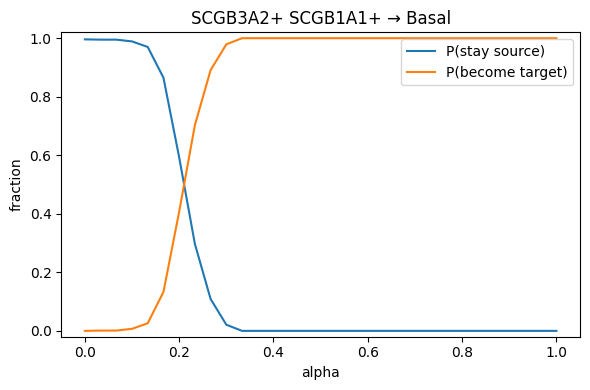

In [22]:
alphas = np.linspace(0, 1.0, 31)

src_ids = adata.obs_names[adata.obs["cell_type"] == "SCGB3A2+ SCGB1A1+"]

res = run_processed_space_experiment(
    adata=adata,
    basis=basis,
    source_cell_ids=src_ids,
    source_label="SCGB3A2+ SCGB1A1+",
    target_label="Basal",
    alphas=alphas,
    max_cells=1000,
    random_state=0,
    filter_to_correct_at_alpha0=False,
    verbose=True,
)

plot_flip_curves(res, "SCGB3A2+ SCGB1A1+ → Basal", output_file='SCGB1A1_to_Basal.png')


[Sanity] alpha=0 P(pred==AT1) = 1.000


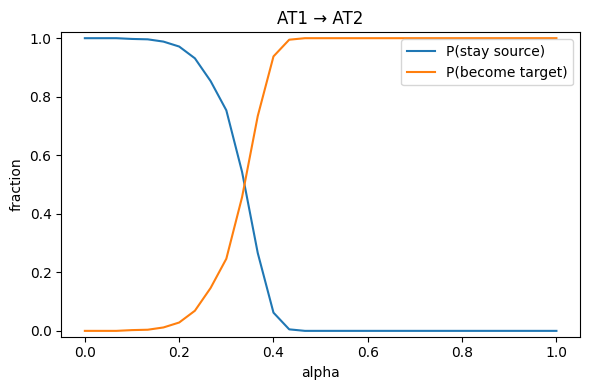

In [21]:
alphas = np.linspace(0, 1.0, 31)

src_ids = adata.obs_names[adata.obs["cell_type"] == "AT1"]

res = run_processed_space_experiment(
    adata=adata,
    basis=basis,
    source_cell_ids=src_ids,
    source_label="AT1",   # MUST match basis.columns exactly
    target_label="AT2",   # MUST match basis.columns exactly
    alphas=alphas,
    max_cells=1000,
    random_state=0,
    filter_to_correct_at_alpha0=False,   # keeps only cells that are correct at baseline
    verbose=True,
)

plot_flip_curves(res, "AT1 → AT2", output_file='AT1_to_AT2.png')


[Sanity] alpha=0 P(pred==Transitional AT2) = 0.421


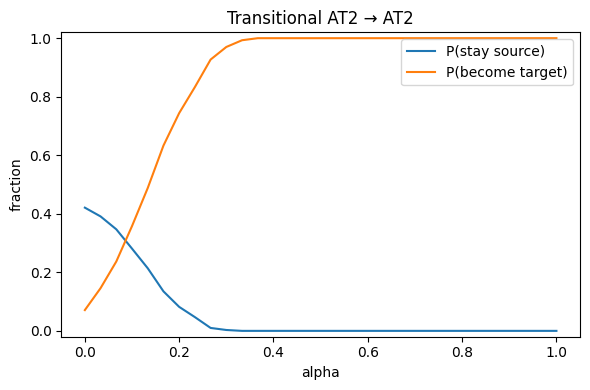

In [22]:
alphas = np.linspace(0, 1.0, 31)

src_ids = adata.obs_names[adata.obs["cell_type"] == "Transitional AT2"]

res = run_processed_space_experiment(
    adata=adata,
    basis=basis,
    source_cell_ids=src_ids,
    source_label="Transitional AT2",   # MUST match basis.columns exactly
    target_label="AT2",   # MUST match basis.columns exactly
    alphas=alphas,
    max_cells=1000,
    random_state=0,
    filter_to_correct_at_alpha0=False,   # keeps only cells that are correct at baseline
    verbose=True,
)

plot_flip_curves(res, "Transitional AT2 → AT2", output_file='Transitional_to_AT2.png')


[Sanity] alpha=0 P(pred==Transitional AT2) = 0.421


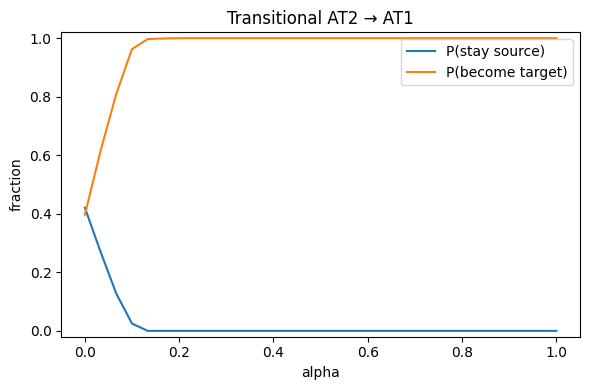

In [23]:
alphas = np.linspace(0, 1.0, 31)

src_ids = adata.obs_names[adata.obs["cell_type"] == "Transitional AT2"]

res = run_processed_space_experiment(
    adata=adata,
    basis=basis,
    source_cell_ids=src_ids,
    source_label="Transitional AT2",   # MUST match basis.columns exactly
    target_label="AT1",   # MUST match basis.columns exactly
    alphas=alphas,
    max_cells=1000,
    random_state=0,
    filter_to_correct_at_alpha0=False,   # keeps only cells that are correct at baseline
    verbose=True,
)

plot_flip_curves(res, "Transitional AT2 → AT1", output_file='Transitional_to_AT1.png')


[Sanity] alpha=0 P(pred==KRT5-/KRT17+) = 0.996


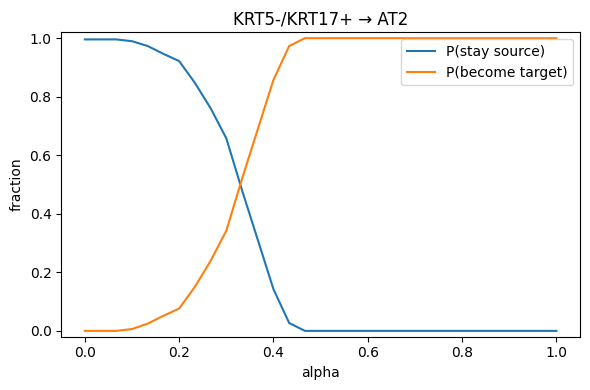

In [26]:
alphas = np.linspace(0, 1.0, 31)

src_ids = adata.obs_names[adata.obs["cell_type"] == "KRT5-/KRT17+"]

res = run_processed_space_experiment(
    adata=adata,
    basis=basis,
    source_cell_ids=src_ids,
    source_label="KRT5-/KRT17+",   # MUST match basis.columns exactly
    target_label="AT2",   # MUST match basis.columns exactly
    alphas=alphas,
    max_cells=1000,
    random_state=0,
    filter_to_correct_at_alpha0=False,   # keeps only cells that are correct at baseline
    verbose=True,
)

plot_flip_curves(res, "KRT5-/KRT17+ → AT2", output_file="ABI_to_AT2.png")


[Sanity] alpha=0 P(pred==KRT5-/KRT17+) = 0.996


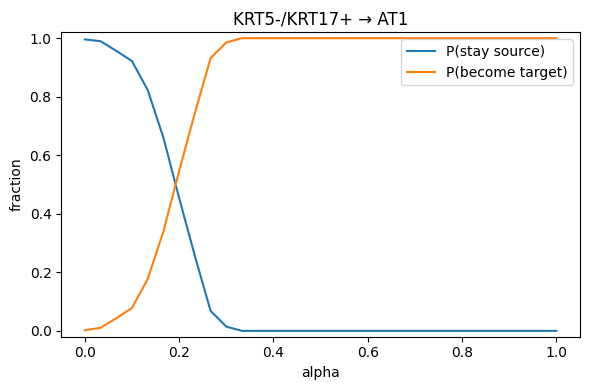

In [27]:
alphas = np.linspace(0, 1.0, 31)

src_ids = adata.obs_names[adata.obs["cell_type"] == "KRT5-/KRT17+"]

res = run_processed_space_experiment(
    adata=adata,
    basis=basis,
    source_cell_ids=src_ids,
    source_label="KRT5-/KRT17+",   # MUST match basis.columns exactly
    target_label="Basal",   # MUST match basis.columns exactly
    alphas=alphas,
    max_cells=1000,
    random_state=0,
    filter_to_correct_at_alpha0=False,   # keeps only cells that are correct at baseline
    verbose=True,
)

plot_flip_curves(res, "KRT5-/KRT17+ → AT1", output_file="ABI_to_AT1.png")


[Sanity] alpha=0 P(pred==KRT5-/KRT17+) = 0.996


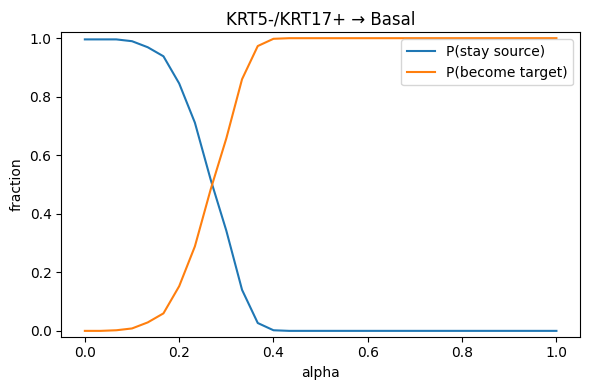

In [28]:
alphas = np.linspace(0, 1.0, 31)

src_ids = adata.obs_names[adata.obs["cell_type"] == "KRT5-/KRT17+"]

res = run_processed_space_experiment(
    adata=adata,
    basis=basis,
    source_cell_ids=src_ids,
    source_label="KRT5-/KRT17+",   # MUST match basis.columns exactly
    target_label="Basal",   # MUST match basis.columns exactly
    alphas=alphas,
    max_cells=1000,
    random_state=0,
    filter_to_correct_at_alpha0=False,   # keeps only cells that are correct at baseline
    verbose=True,
)

plot_flip_curves(res, "KRT5-/KRT17+ → Basal", output_file="ABI_to_Basal.png")


In [29]:
adata = ad.read_h5ad('/projectnb/biophys/Huan/scTOP/planer_reduced.h5ad')

In [32]:
basis

,AT2,AT1_AT2,AT1,Alveolar_transitional,Krt5
4933401J01RIK,-0.002502,-0.002453,-0.002438,-0.002351,-0.002549
GM26206,-0.002502,-0.002453,-0.002438,-0.002351,-0.002549
XKR4,0.002225,0.002341,-0.002438,-0.002351,0.002632
GM18956,-0.002502,-0.002453,-0.002438,-0.002351,-0.002549
GM37180,-0.002502,0.002341,-0.002438,0.003421,0.002117
...,...,...,...,...,...
MT-ND6,0.009510,0.007712,0.007396,0.007670,0.009335
MT-TE,-0.002502,-0.002453,-0.002438,-0.002351,-0.002549
MT-CYTB,0.019343,0.019437,0.019302,0.019829,0.019092
MT-TT,-0.002502,-0.002453,-0.002438,-0.002351,-0.002549


[Sanity] alpha=0 P(pred==AT1_AT2) = 0.545


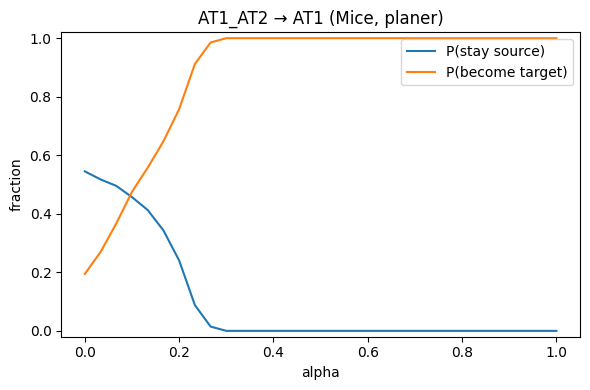

In [36]:
alphas = np.linspace(0, 1.0, 31)

src_ids = adata.obs_names[adata.obs["cell_type"] == "AT1_AT2"]

res = run_processed_space_experiment(
    adata=adata,
    basis=basis,
    source_cell_ids=src_ids,
    source_label="AT1_AT2",   # MUST match basis.columns exactly
    target_label="AT1",   # MUST match basis.columns exactly
    alphas=alphas,
    max_cells=1000,
    random_state=0,
    filter_to_correct_at_alpha0=False,   # keeps only cells that are correct at baseline
    verbose=True,
)

plot_flip_curves(res, "AT1_AT2 → AT1 (Mice, planer)", output_file="AT1_AT2_to_AT1_planer.png")
